In [1]:
import geopandas
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib import cm
import numpy as np
import shapely
from shapely.geometry import Polygon
import pandas as pd

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    #"font.serif": ["Latin Modern Roman"],
    "font.serif": ["CMU Serif"],
    "font.size" : 10,
    "figure.dpi" : 300,
    "hatch.color" : '0.2',
    "hatch.linewidth" : 0.5
})

def get_figsize(fig_ratio=1/2.414, text_width_ratio=1, orientation='landscape'):
    text_width = 210 - 30 - 20 # A4 - bordas
    width_inch = (text_width * text_width_ratio) / 25.4
    if orientation == 'landscape':
        height_inch = width_inch * fig_ratio
    elif orientation == 'portrait':
        height_inch = width_inch * fig_ratio
    else:
        raise ValueError("orientation must be 'landscape' or 'portrait'") 
        
    return width_inch, height_inch



%matplotlib notebook

In [2]:
info_file = './dados/survey_info.csv'

survey_info = pd.read_csv(info_file, sep='\t')
#survey_info.loc[survey_info['area'] == 'Mar do Caribe', 'split'] = 'Validação'

<IPython.core.display.Javascript object>


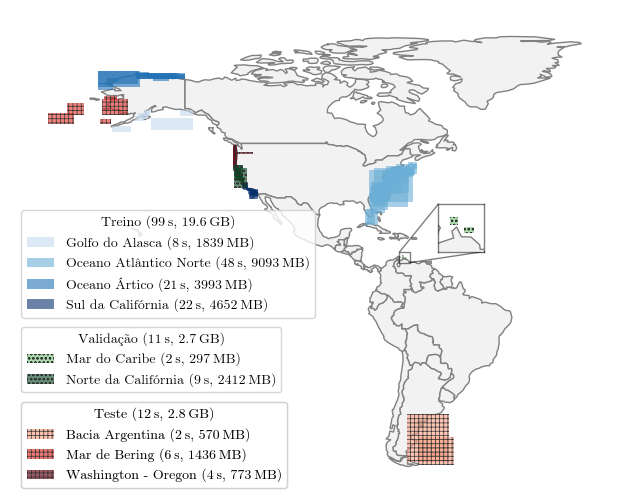

Salvo arquivo ./figuras/survey_map.pdf


In [8]:
save_file = None
save_file = './figuras/survey_map.pdf'

figsize = get_figsize(fig_ratio=0.8, orientation='portrait')
#figsize = get_figsize(fig_ratio=0.8, text_width_ratio=0.5, orientation='portrait')

column_color = 'area'
america_color = '0.95'
alpha = 0.6
cmap = 'tab20'

split_order = ['Treino', 'Validação', 'Teste']
split_palette = {'Treino':'Blues', 'Validação':'Greens', 'Teste':'Reds'}
split_hatch = {'Treino':None, 'Validação':'oooo', 'Teste':'++++'}
split_loc = {'Treino':(0,0.36), 'Validação':(0,0.246), 'Teste':(0,0)}
split_loc = {'Treino':(0,0.36), 'Validação':(0,0.202), 'Teste':(0,0)}

world = geopandas.read_file(geopandas.datasets.get_path("naturalearth_lowres"))
america = world[world.continent.str.contains('America')]

polys = []
for _, row in survey_info.iterrows():
    minx = row.eastLong
    miny = row.southLat
    maxx = row.westLong
    maxy = row.northLat
    polys.append(shapely.geometry.box(minx, miny, maxx, maxy))
    
survey_bboxes = geopandas.GeoDataFrame(survey_info, geometry=polys, crs=america.crs)

fig, ax = plt.subplots(1, 1, figsize=figsize)


# Plota o continente
america.plot(ax=ax, color=america_color, edgecolor='gray')


# Plota as regiões por separação
group = survey_info.groupby('area', as_index=False)
area_info = group.agg({'split' : lambda x:pd.Series.unique(x)[0], 'clean_size' : 'sum', 'survey':'count'})
for split in split_order:
    info = area_info[area_info['split'] == split]
    #split_cmap = ListedColormap(cmap(area_info[area_info['area'].isin(info['area'])].index))
    split_cmap = cm.get_cmap(split_palette[split], len(info)+1)
    split_cmap = ListedColormap(split_cmap(range(1,len(info)+1)))
    #get_label = lambda a:"{} ({}$\,$s, {:.0f}$\,$MB)".format(a['area'], a['survey'], a['clean_size'])
    #title = "{} ({}$\,$s, {:.1f}$\,$GB)".format(split, info['survey'].sum(), info['clean_size'].sum()/10**3 )
    thinspace = '\u2009' 
    get_label = lambda a:u"{0} ({1}{3}s, {2:.0f}{3}MB)".format(a['area'], a['survey'], a['clean_size'], thinspace)
    title = "{0} ({1}{3}s, {2:.1f}{3}GB)".format(split, info['survey'].sum(), info['clean_size'].sum()/10**3, thinspace)
    handles = [mpatches.Patch(facecolor=split_cmap(i), hatch=split_hatch[split], alpha=alpha, label=get_label(a)) 
               for i, (_,a) in enumerate(info.iterrows())]
    legend = ax.legend(handles=handles, loc=split_loc[split], title=title)
    ax.add_artist(legend)
    survey_bboxes[survey_bboxes['split'] == split].plot(column_color, ax=ax, cax=ax, alpha=alpha,
                                                        cmap=split_cmap, marker='s', legend=False,
                                                        hatch=split_hatch[split])
    
# Plota zoom do mar do caribe
zoom_box_color = '0.0'
zoom_box_alpha = 0.5
zoom_box_linewidth = 1
split = area_info.loc[area_info['area'] == 'Mar do Caribe', 'split'].values[0]
xorig, yorig, size_orig = -71.3, 10.4, 3.4
xax_loc, yax_loc, size_ax = 0.7, 0.5, 0.1

info = area_info[area_info['split'] == split]
split_cmap = cm.get_cmap(split_palette[split], len(info)+1)
split_cmap = ListedColormap(split_cmap(range(1,len(info)+1)))

zoom_box = ax.inset_axes([xax_loc, yax_loc, size_ax, size_ax])
zoom_box.set_xlim(xorig, xorig + size_orig)
zoom_box.set_ylim(yorig, yorig + size_orig)
zoom_box.set_xticks([])
zoom_box.set_yticks([])
zoom_box.spines[['top', 'right', 'left', 'bottom']].set_color(zoom_box_color) 
zoom_box.spines[['top', 'right', 'left', 'bottom']].set_alpha(zoom_box_alpha) 
zoom_box.spines[['top', 'right', 'left', 'bottom']].set_linewidth(zoom_box_linewidth) 
#zoom_box.spines[['top', 'right', 'left', 'bottom']].set(alpha=0.5, color=zoom_box_color) 

survey_bboxes[survey_bboxes['split'] == split].plot(column_color, ax=zoom_box, cax=zoom_box, alpha=alpha,
                                                    cmap=split_cmap, marker='s', legend=False,
                                                    hatch=split_hatch[split])
america.plot(ax=zoom_box, color=america_color, edgecolor='gray')
ax.indicate_inset_zoom(zoom_box, edgecolor=zoom_box_color, alpha=zoom_box_alpha, linewidth=zoom_box_linewidth)
    
ax.set_axis_off()
plt.tight_layout()

if not save_file:
    plt.show()
else:
    plt.savefig(save_file)
    print("Salvo arquivo", save_file)

In [ ]:
# Tabela: tamanho de cada conjunto
split_size = survey_info.groupby('split')['clean_size'].sum()

for s in split_order:
    print("{}\t{:.1f} GB".format(s, split_size[s]/1000))
print()
print("{}\t{:.1f} GB".format('Total', split_size.sum()/1000))

In [ ]:
# Tabela: tamanho e split de cada área
group = survey_info.groupby('area')
area_info = group.agg({'split' : 'unique', 'clean_size' : 'sum', 'survey' : 'count'})
for _, row in area_info.iterrows():
    #print(row.name, row.split[0], "{:.2f} GB".format(row.clean_size/1000))
    print(row.name, row.split[0], "{:.0f} MB".format(row.clean_size), sep='\t')

In [ ]:
# Tabela: tamanho e split de cada área
group = survey_info.groupby('area')
area_info = group.agg({'split' : 'unique', 'clean_size' : 'sum', 'survey' : 'count'})
print(area_info)

In [ ]:
group = survey_bboxes.groupby('suffix')
print(group.agg({'suffix' : 'count', 'clean_size' : 'sum'}))